# RF Model

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, r2_score

## Data Stuff

In [23]:
#BRING IN THE MOTHER
mother_file = pd.read_csv("data/one_hot_mama.csv")
#michelena test
#mother_file = pd.read_csv("data/mother_with_salaries.csv")
mother_file

# removing a ton of columns that are not helpful
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_value_tonnes' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'capacity_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_total_material' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_grade' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_mineral_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_commodity_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'commodities_grade' in col])
mother_file

,facility_id,primary_commodity,country,mining_salary,LOM_in_Buckets,still_operating,2000_Concentrate,2001_Concentrate,2002_Concentrate,2003_Concentrate,...,primary_commodity_Aluminium,primary_commodity_Coal,primary_commodity_Copper,primary_commodity_Gold,primary_commodity_Iron,primary_commodity_Nickel,primary_commodity_Other (poly)-metallic,primary_commodity_Other mine,primary_commodity_Silver,primary_commodity_Zinc
0,COM00003.00,Coal,United States of America,55819.00,47.0,1.0,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,COM00008.00,Nickel,Spain,37500.00,11.0,0.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,COM00009.00,Gold,Ghana,4509.60,15.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,COM00015.00,Copper,Kazakhstan,12877.81,6.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,COM00016.00,Gold,Ghana,4509.60,8.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,COM01415.00,Coal,Russian Federation,11616.07,68.0,1.0,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
398,COM01418.00,Gold,Tajikistan,2811.72,14.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
399,COM01419.00,Coal,China,19604.88,12.0,1.0,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
400,COM01430.00,Gold,China,19604.88,41.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
# Split on facility_id
facilities = mother_file["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

train_df = mother_file[mother_file["facility_id"].isin(train_facilities)]
test_df  = mother_file[mother_file["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
y_train = train_df["LOM_in_Buckets"]
y_test  = test_df["LOM_in_Buckets"]
drop_cols = ["LOM_in_Buckets"]
# Drop unwanted columns (found after other data processing steps)to create feature matrices
X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test  = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = y_train.notna()
mask_test  = y_test.notna()
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test,  y_test  = X_test[mask_test],  y_test[mask_test]

# Fill NaNs in features with training median
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print(f"\nFeatures used : {list(X_train.columns)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")

Train rows : 321 (321 facilities)
Test rows  : 81 (81 facilities)

Features used : ['mining_salary', 'still_operating', '2000_Concentrate', '2001_Concentrate', '2002_Concentrate', '2003_Concentrate', '2004_Concentrate', '2005_Concentrate', '2006_Concentrate', '2007_Concentrate', '2008_Concentrate', '2009_Concentrate', '2010_Concentrate', '2011_Concentrate', '2012_Concentrate', '2013_Concentrate', '2014_Concentrate', '2015_Concentrate', '2016_Concentrate', '2017_Concentrate', '2018_Concentrate', '2019_Concentrate', '2020_Concentrate', '2000_Ore processed', '2001_Ore processed', '2002_Ore processed', '2003_Ore processed', '2004_Ore processed', '2005_Ore processed', '2006_Ore processed', '2007_Ore processed', '2008_Ore processed', '2009_Ore processed', '2010_Ore processed', '2011_Ore processed', '2012_Ore processed', '2013_Ore processed', '2014_Ore processed', '2015_Ore processed', '2016_Ore processed', '2017_Ore processed', '2018_Ore processed', '2019_Ore processed', '2020_Ore processed'

# For Loop Different Feature Combinations

In [25]:
import re
from itertools import combinations

# Group year-prefixed columns and one-hot encoded categories by their base feature name.
YEAR_PREFIX_RE = re.compile(r'^(\d{4})_(.+)$')

def base_feature_name(column_name):
    match = YEAR_PREFIX_RE.match(column_name)
    if match:
        return match.group(2)
    if column_name.startswith('country_'):
        return 'country'
    if column_name.startswith('primary_commodity_'):
        return 'primary_commodity'
    return column_name

numeric_feature_cols = [
    col for col in mother_file.select_dtypes(include='number').columns
    if col != 'LOM_in_Buckets'
]
feature_groups = {}
for col in numeric_feature_cols:
    group_name = base_feature_name(col)
    feature_groups.setdefault(group_name, []).append(col)

print(f"Found {len(feature_groups)} numeric feature groups")
for group_name, cols in sorted(feature_groups.items(), key=lambda item: (-len(item[1]), item[0])):
    print(f"{group_name}: {len(cols)} columns")

feature_group_names = sorted(feature_groups)


Found 17 numeric feature groups
country: 46 columns
Concentrate: 21 columns
Ore processed: 21 columns
coal_mined_value_tonnes: 21 columns
commodities_grade_ppm: 21 columns
commodities_recovery_rate: 21 columns
commodities_value_tonnes: 21 columns
minerals_ore_mined_value_tonnes: 21 columns
price_usd_tonne: 21 columns
reserves_mineral_value_tonnes: 21 columns
waste_total_material_tonnes: 19 columns
waste_value_tonnes: 19 columns
reserves_commodity_value_tonnes: 15 columns
reserves_grade_ppm: 15 columns
primary_commodity: 10 columns
mining_salary: 1 columns
still_operating: 1 columns


In [26]:
import heapq

# Evaluate combinations of grouped feature sets to find the best group-level features.
# This keeps year-suffixed columns together as one group.
preferred_order = [
    'primary_commodity',
    'mining_salary',
    'price_usd_tonne',
    'still_operating',
    'country',
    'reserves_commodity_value_tonnes',
    'minerals_concentrate_value_tonnes',
    'minerals_ore_mined_value_tonnes',
    'minerals_ore_processed_value_tonnes',
    'clean_coal_value_tonnes',
    'coal_mined_value_tonnes',
]

remaining_groups = [
    g for g in feature_group_names
    if g not in preferred_order and g not in {'facility_id', 'LOM_in_Buckets'}
]

search_groups = [g for g in preferred_order if g in feature_group_names] + remaining_groups
print(f"Searching combinations over {len(search_groups)} feature groups")

best_results = []
max_results = 20
for r in range(1, min(4, len(search_groups)) + 1):
    for combo in combinations(search_groups, r):
        selected_cols = [col for group in combo for col in feature_groups[group]]
        X_train_combo = train_df[selected_cols].select_dtypes(include='number').copy()
        X_test_combo = test_df[selected_cols].select_dtypes(include='number').copy()

        X_train_combo = X_train_combo.replace([np.inf, -np.inf], np.nan)
        X_test_combo = X_test_combo.replace([np.inf, -np.inf], np.nan)

        model_combo = RandomForestRegressor(random_state=42, n_estimators=100)
        model_combo.fit(X_train_combo, y_train)
        score = r2_score(y_test, model_combo.predict(X_test_combo))

        record = {
            'feature_groups': combo,
            'num_columns': len(selected_cols),
            'r2_test': score,
        }

        if len(best_results) < max_results:
            heapq.heappush(best_results, (score, record))
        else:
            heapq.heappushpop(best_results, (score, record))

best_sorted = [record for score, record in sorted(best_results, key=lambda x: x[0], reverse=True)]
combo_df = pd.DataFrame(best_sorted)
print(combo_df.to_string(index=False))

# Save only the top results to keep the output file small.
combo_df.to_csv('data/feature_group_combo_results.csv', index=False)
print('Saved top 20 feature-group combo results to data/feature_group_combo_results.csv')


Searching combinations over 17 feature groups
                                                                                                          feature_groups  num_columns  r2_test
                                                      (primary_commodity, country, coal_mined_value_tonnes, Concentrate)           98 0.177925
                    (country, reserves_commodity_value_tonnes, minerals_ore_mined_value_tonnes, coal_mined_value_tonnes)          103 0.176239
                                  (primary_commodity, country, reserves_commodity_value_tonnes, coal_mined_value_tonnes)           92 0.173182
                                                  (primary_commodity, still_operating, country, coal_mined_value_tonnes)           78 0.159289
                             (mining_salary, coal_mined_value_tonnes, reserves_grade_ppm, reserves_mineral_value_tonnes)           58 0.157667
               (coal_mined_value_tonnes, reserves_grade_ppm, reserves_mineral_value_tonnes, wast

In [27]:
# Save the best model's training and test data
best_combo = best_sorted[0]['feature_groups']
best_combo_cols = [col for group in best_combo for col in feature_groups[group]]

X_train_best = train_df[best_combo_cols].select_dtypes(include='number').copy()
X_test_best = test_df[best_combo_cols].select_dtypes(include='number').copy()

X_train_best = X_train_best.replace([np.inf, -np.inf], np.nan)
X_test_best = X_test_best.replace([np.inf, -np.inf], np.nan)

y_train_best = y_train
y_test_best = y_test

# Save to CSV files
# X_train_best.to_csv('data/best_X_train.csv', index=False)
# X_test_best.to_csv('data/best_X_test.csv', index=False)
# y_train_best.to_csv('data/best_y_train.csv', index=False)
# y_test_best.to_csv('data/best_y_test.csv', index=False)

print(f"Saved best model data:")
print(f"  Best feature groups: {best_combo}")
print(f"  X_train shape: {X_train_best.shape}")
print(f"  X_test shape: {X_test_best.shape}")
print(f"  y_train shape: {y_train_best.shape}")
print(f"  y_test shape: {y_test_best.shape}")
print(f"  Best R^2: {best_sorted[0]['r2_test']}")


Saved best model data:
  Best feature groups: ('primary_commodity', 'country', 'coal_mined_value_tonnes', 'Concentrate')
  X_train shape: (321, 98)
  X_test shape: (81, 98)
  y_train shape: (321,)
  y_test shape: (81,)
  Best R^2: 0.17792515915058182


# Plot For Loop Model

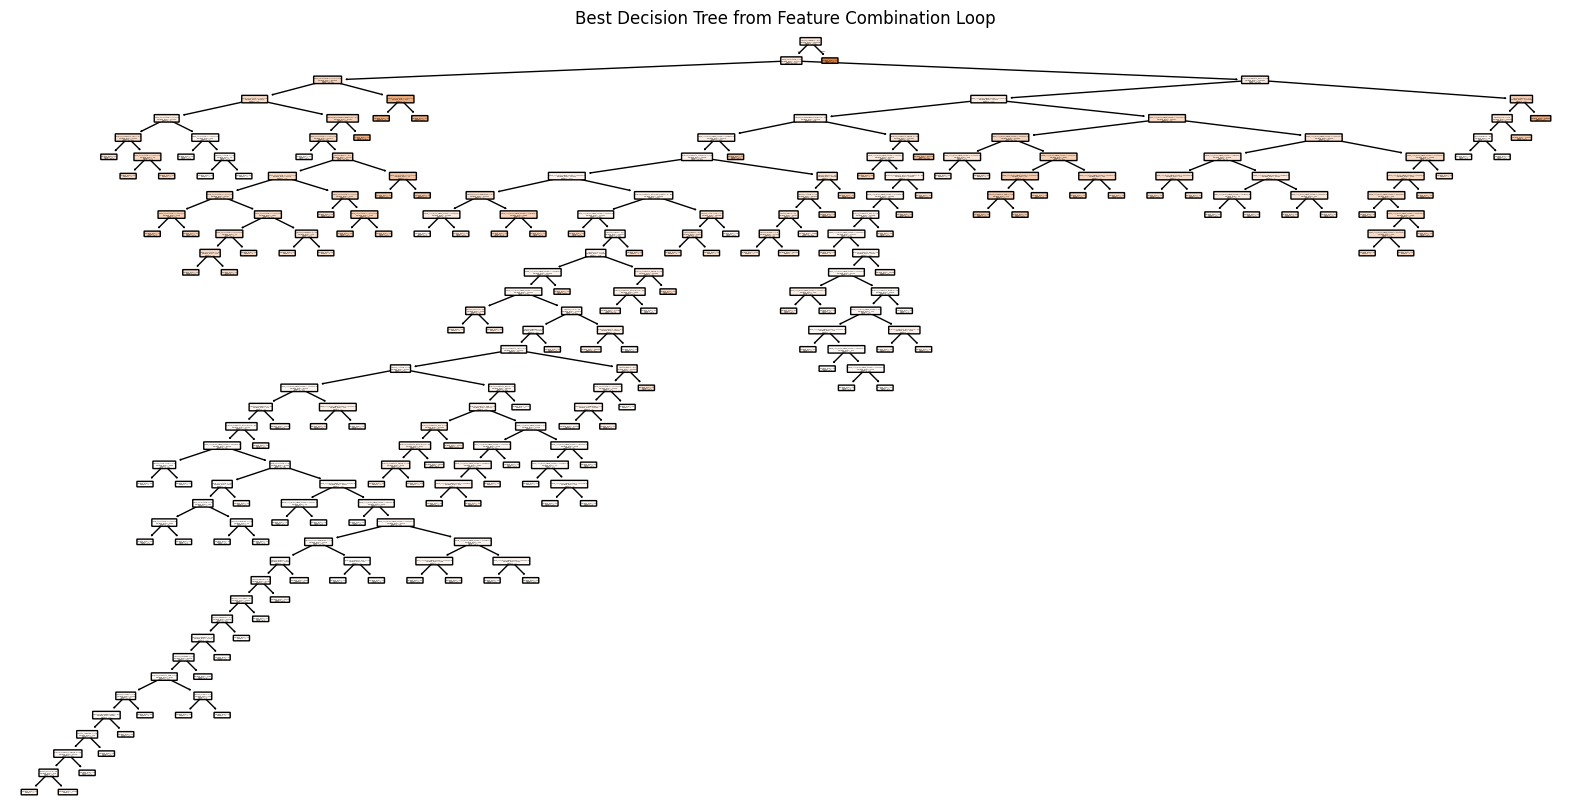

In [28]:
# Plot the best decision tree from the feature combination loop
best_tree_model = RandomForestRegressor(random_state=42, n_estimators=100)
best_tree_model.fit(X_train_best, y_train_best)

best_tree = best_tree_model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(best_tree,
          filled=True,              
          feature_names=X_train_best.columns.tolist(),
          rounded=True)             
plt.title("Best Decision Tree from Feature Combination Loop")
plt.show()


In [29]:
# we're having some trouble with X, let's see what it is -- as it turns out, some values were infinite
#print(X_train)
pd.DataFrame(X_train).to_csv('data/X_train_check.csv', index=False)

# Base Model with Random Forest

In [30]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
# print(y_pred_train)
# print(y_pred_test)

print('R^2 train:', r2_score(y_train, y_pred_train))
print('R^2 test :', r2_score(y_test, y_pred_test))

# accuracy_train_grid = accuracy_score(y_train, y_pred_train)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test)


R^2 train: 0.8381452343016913
R^2 test : 0.10237590931053075


# Random Forest with Param Grid Attribute

In [31]:
# # adapted from Pset 1 Q3 and Pset 3 Q3
param_grid = {
    'max_depth': (1, 3, 5, 10),
    'min_samples_leaf': (1, 5, 20)
    # 'criterion': (“squared_error”, “absolute_error”, “friedman_mse”, “poisson”)
}

tree = RandomForestRegressor()
grid_tree = GridSearchCV(estimator=tree,
                         param_grid=param_grid,
                         scoring='r2',
                         cv=5)

grid_tree.fit(X_train,y_train)
grid_model = grid_tree.best_estimator_

y_pred_train_grid = grid_model.predict(X_train)
y_pred_test_grid = grid_model.predict(X_test)

# accuracy_train_grid = accuracy_score(y_train, y_pred_train_grid)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test_grid)

print("best accuracy", grid_tree.best_score_)
print("best params", grid_tree.best_params_)
print('Grid R^2 train:', r2_score(y_train, y_pred_train_grid))
print('Grid R^2 test :', r2_score(y_test, y_pred_test_grid))


# print(f'Train Accuracy = {accuracy_train_grid}')
# print(f'Test Accuracy = {accuracy_test_grid}')


best accuracy 0.18443127250799804
best params {'max_depth': 5, 'min_samples_leaf': 20}
Grid R^2 train: 0.23004688351615576
Grid R^2 test : 0.0831369326918251


# Plot the Random Forest with Best Param Grid Attributes (highest R^2)

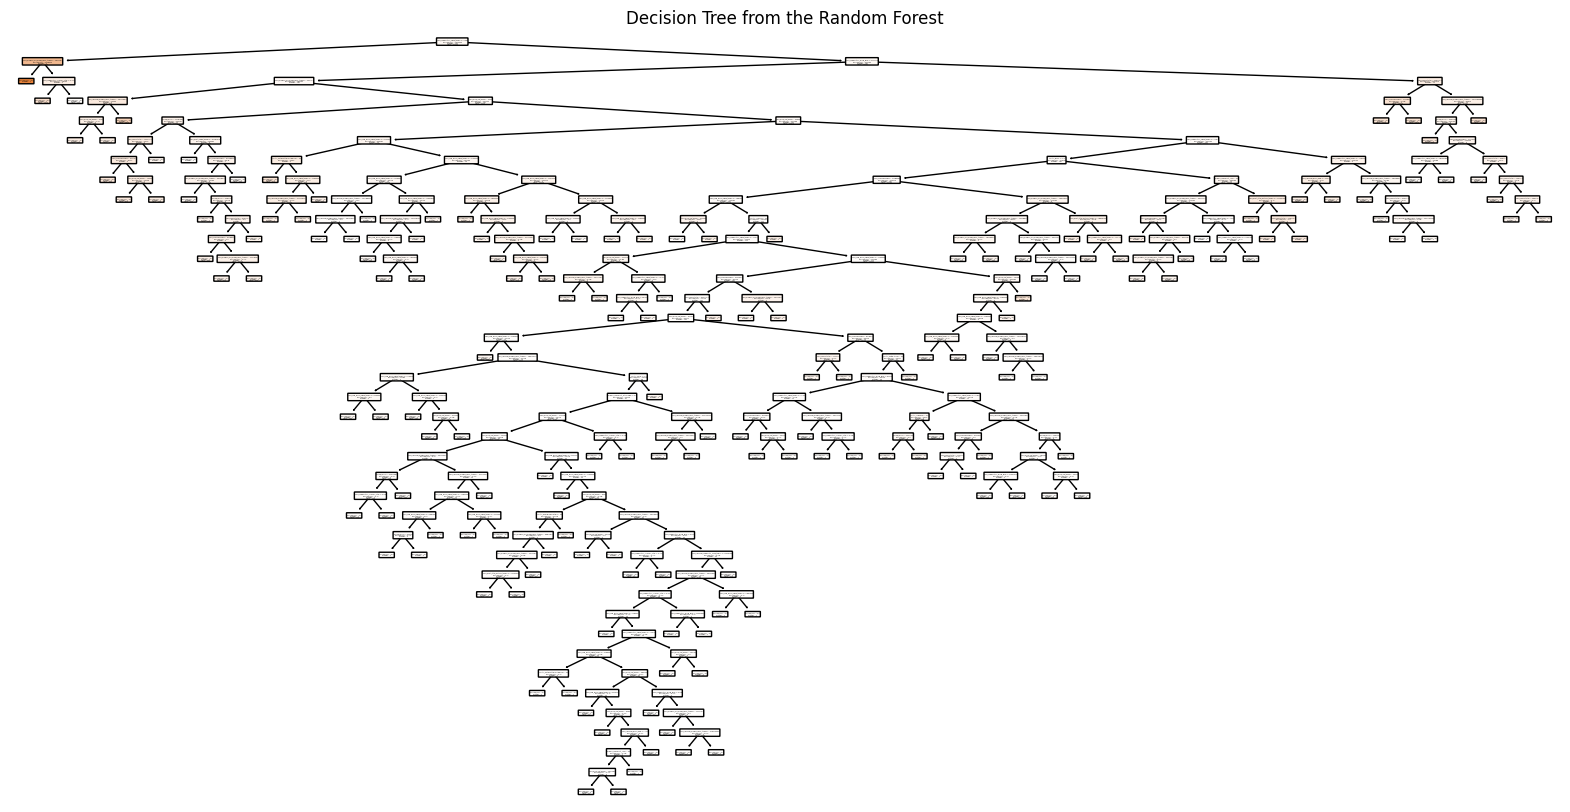

In [32]:
tree = model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             # make things pretty
plt.title("Decision Tree from the Random Forest")
plt.show()

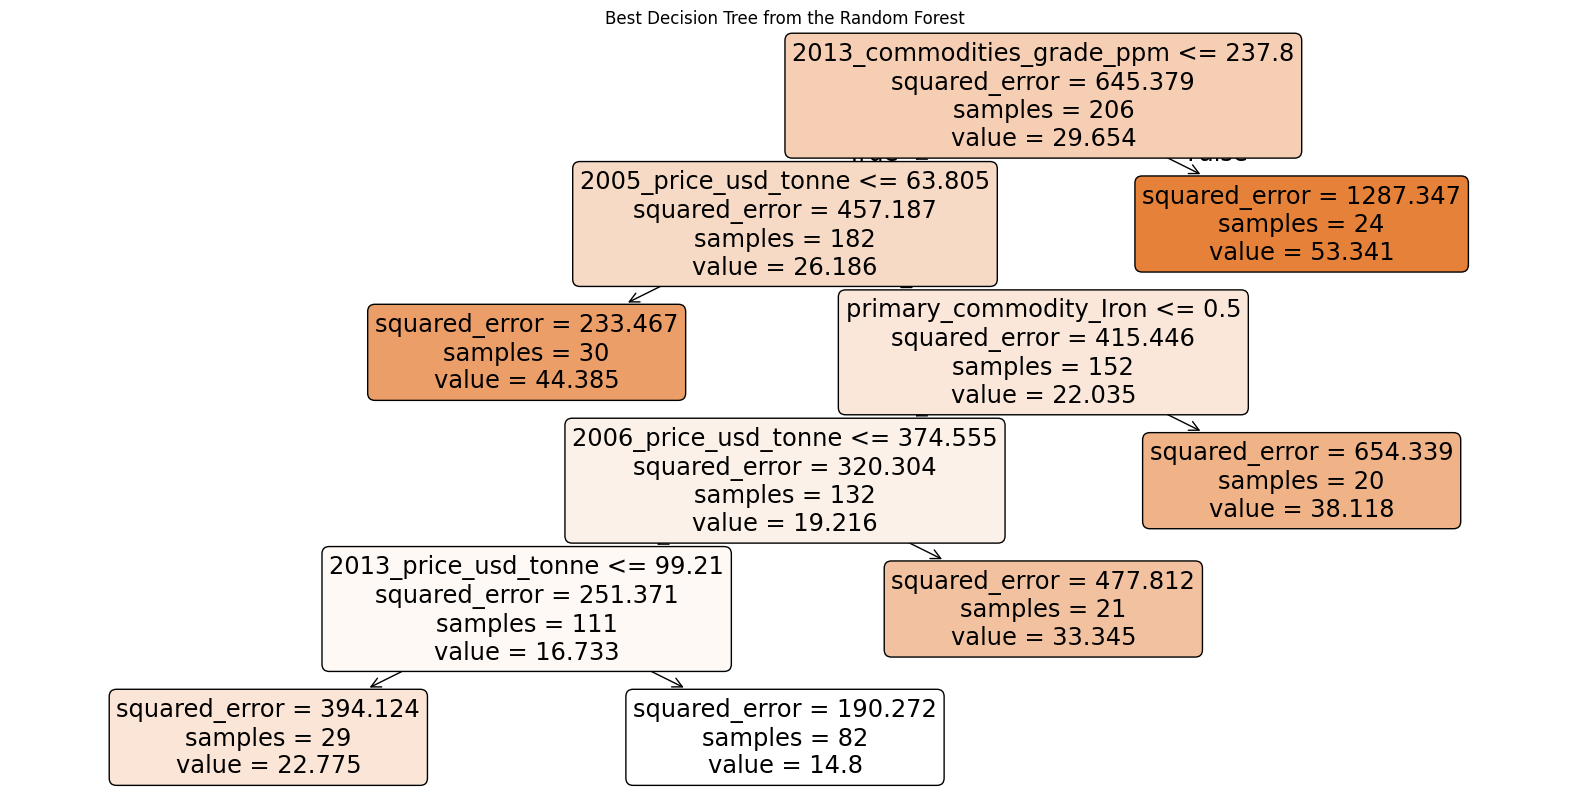

In [33]:
grid_tree = grid_model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(grid_tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             
plt.title("Best Decision Tree from the Random Forest")
plt.show()

## Spliting data on if still_operating variable is a 1 or 0 for open or closed mines

In [43]:
#separate data into rows with mine closure and mines without
df = pd.read_csv('data/for_loop_data.csv')

still_operating = df[df['still_operating'] == 1]
closed = df[df['still_operating'] == 0]

still_operating.to_csv('data/for_loop_data_operating.csv', index=False)
closed.to_csv('data/for_loop_data_closed.csv', index=False)

print(f'Operating mines: {len(still_operating)} rows -> one_hot_mama_operating.csv')
print(f'Closed mines:    {len(closed)} rows -> one_hot_mama_closed.csv')



Operating mines: 374 rows -> one_hot_mama_operating.csv
Closed mines:    28 rows -> one_hot_mama_closed.csv


## Radmon Forest on Only Mine without Closing Data

In [35]:
# Split on facility_id
facilities = still_operating["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

open_train_df = still_operating[still_operating["facility_id"].isin(train_facilities)]
open_test_df  = still_operating[still_operating["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(open_train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(open_test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
open_y_train = open_train_df["LOM_in_Buckets"]
open_y_test  = open_test_df["LOM_in_Buckets"]
drop_cols = ["LOM_in_Buckets"]
# Drop unwanted columns (found after other data processing steps)to create feature matrices
open_X_train = open_train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
open_X_test  = open_test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
open_X_train = open_X_train.replace([np.inf, -np.inf], np.nan)
open_X_test = open_X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = open_y_train.notna()
mask_test  = open_y_test.notna()
open_X_train, open_y_train = open_X_train[mask_train], open_y_train[mask_train]
open_X_test,  open_y_test  = open_X_test[mask_test],  open_y_test[mask_test]

# Fill NaNs in features with training median
open_X_train = open_X_train.fillna(open_X_train.median())
open_X_test  = open_X_test.fillna(open_X_train.median())

Train rows : 299 (299 facilities)
Test rows  : 75 (75 facilities)


In [36]:
open_model = RandomForestRegressor()
open_model.fit(open_X_train, open_y_train)

open_y_pred_train = open_model.predict(open_X_train)
open_y_pred_test  = open_model.predict(open_X_test)

print('R^2 train:', r2_score(open_y_train, open_y_pred_train))
print('R^2 test :', r2_score(open_y_test,  open_y_pred_test))

R^2 train: 0.8237885234170668
R^2 test : 0.10241622866823563


In [37]:
# # adapted from Pset 1 Q3 and Pset 3 Q3
param_grid = {
    'max_depth': (1, 3, 5, 10),
    'min_samples_leaf': (1, 5, 20)
    # 'criterion': (“squared_error”, “absolute_error”, “friedman_mse”, “poisson”)
}

open_tree = RandomForestRegressor()
open_grid_tree = GridSearchCV(estimator=open_tree,
                         param_grid=param_grid,
                         scoring='r2',
                         cv=5)

open_grid_tree.fit(open_X_train, open_y_train)
open_grid_model = open_grid_tree.best_estimator_

y_pred_train_grid = open_grid_model.predict(open_X_train)
y_pred_test_grid = open_grid_model.predict(open_X_test)

print("best accuracy", open_grid_tree.best_score_)
print("best params", open_grid_tree.best_params_)
print('Grid R^2 train:', r2_score(open_y_train, y_pred_train_grid))
print('Grid R^2 test :', r2_score(open_y_test, y_pred_test_grid))

best accuracy 0.1767002401340988
best params {'max_depth': 10, 'min_samples_leaf': 5}
Grid R^2 train: 0.44806021818961583
Grid R^2 test : 0.2833934944812645


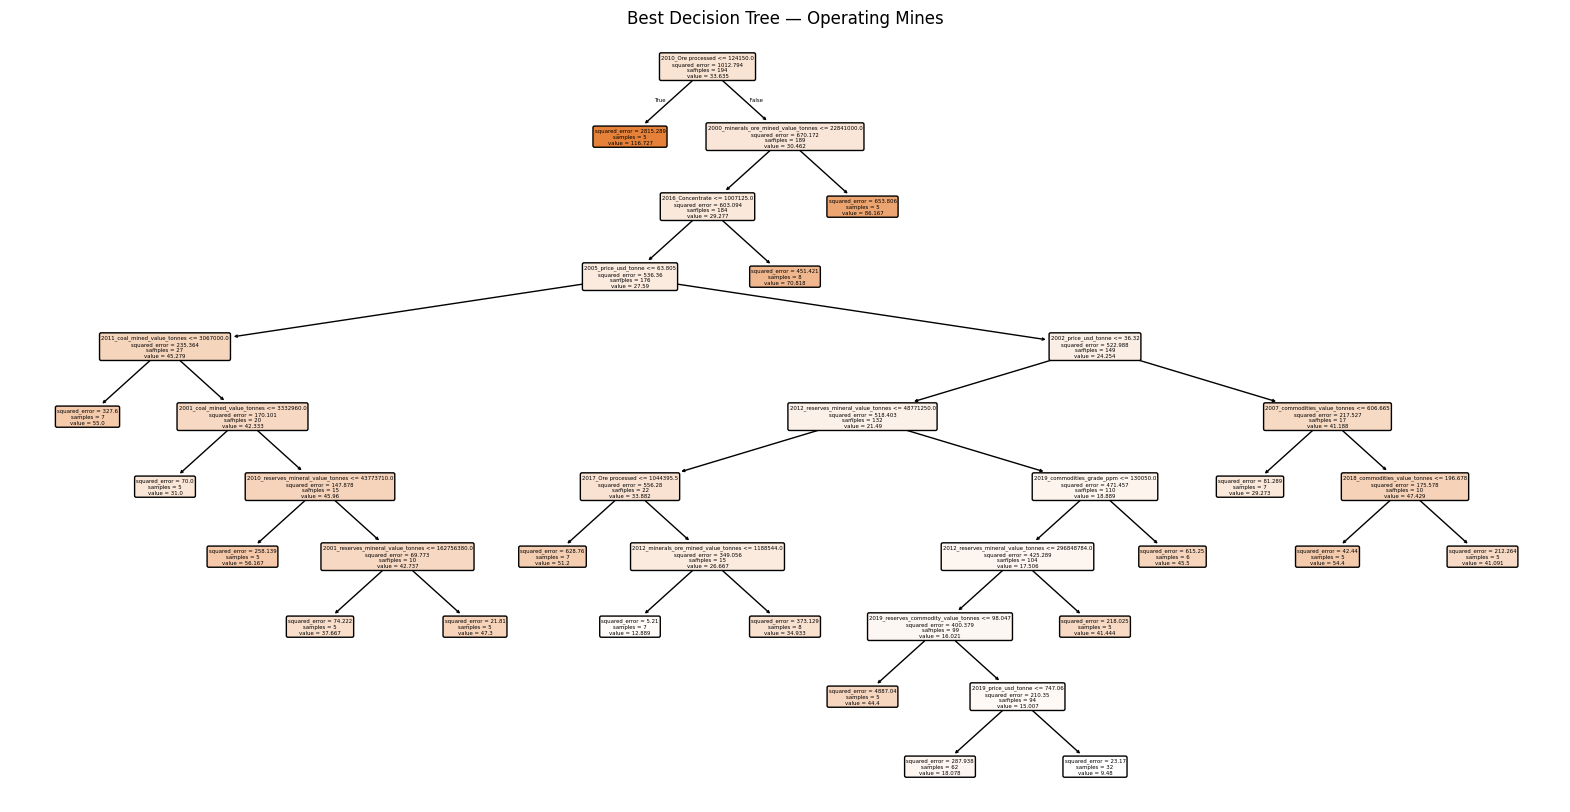

In [38]:
open_best_tree = open_grid_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(open_best_tree,
          filled=True,
          feature_names=open_X_train.columns.tolist(),
          rounded=True)
plt.title('Best Decision Tree — Operating Mines')
plt.show()

## Random Forest on Only Mines with Closing Data

In [39]:
# Same model as above but run with alternative file
# Split on facility_id
facilities = closed["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

closed_train_df = closed[closed["facility_id"].isin(train_facilities)]
closed_test_df  = closed[closed["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(closed_train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(closed_test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
closed_y_train = closed_train_df["LOM_in_Buckets"]
closed_y_test  = closed_test_df["LOM_in_Buckets"]
drop_cols = ["LOM_in_Buckets"]
# Drop unwanted columns (found after other data processing steps)to create feature matrices
closed_X_train = closed_train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
closed_X_test  = closed_test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
closed_X_train = closed_X_train.replace([np.inf, -np.inf], np.nan)
closed_X_test = closed_X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = closed_y_train.notna()
mask_test  = closed_y_test.notna()
closed_X_train, closed_y_train = closed_X_train[mask_train], closed_y_train[mask_train]
closed_X_test,  closed_y_test  = closed_X_test[mask_test],  closed_y_test[mask_test]

# Fill NaNs in features with training median
closed_X_train = closed_X_train.fillna(closed_X_train.median())
closed_X_test  = closed_X_test.fillna(closed_X_train.median())

Train rows : 22 (22 facilities)
Test rows  : 6 (6 facilities)


In [40]:
closed_model = RandomForestRegressor()
closed_model.fit(closed_X_train, closed_y_train)

closed_y_pred_train = closed_model.predict(closed_X_train)
closed_y_pred_test  = closed_model.predict(closed_X_test)

print('R^2 train:', r2_score(closed_y_train, closed_y_pred_train))
print('R^2 test :', r2_score(closed_y_test,  closed_y_pred_test))

R^2 train: 0.523137568460619
R^2 test : -1.111784809208737


In [41]:
param_grid = {
    'max_depth': (1, 3, 5, 10),
    'min_samples_leaf': (1, 5, 20)
    # 'criterion': (“squared_error”, “absolute_error”, “friedman_mse”, “poisson”)
}

closed_tree = RandomForestRegressor()
closed_grid_tree = GridSearchCV(estimator=closed_tree,
                         param_grid=param_grid,
                         scoring='r2',
                         cv=5)

closed_grid_tree.fit(closed_X_train, closed_y_train)
closed_grid_model = closed_grid_tree.best_estimator_

y_pred_train_grid = closed_grid_model.predict(closed_X_train)
y_pred_test_grid = closed_grid_model.predict(closed_X_test)

print("best accuracy", closed_grid_tree.best_score_)
print("best params", closed_grid_tree.best_params_)
print('Grid R^2 train:', r2_score(closed_y_train, y_pred_train_grid))
print('Grid R^2 test :', r2_score(closed_y_test, y_pred_test_grid))

best accuracy -1.5504436611471815
best params {'max_depth': 10, 'min_samples_leaf': 1}
Grid R^2 train: 0.5977848902584799
Grid R^2 test : -1.3486498323212182


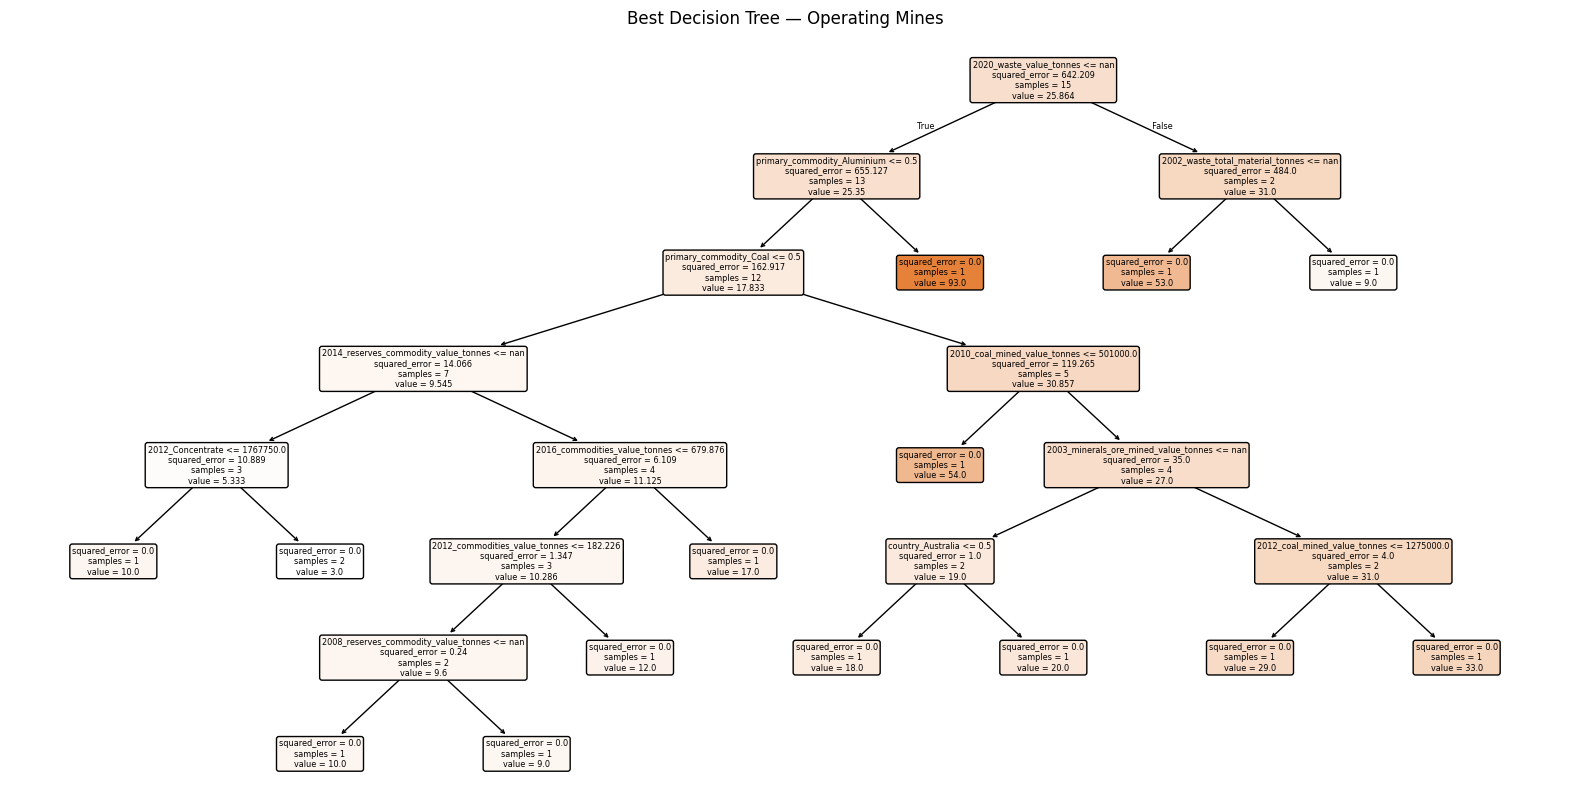

In [42]:
closed_best_tree = closed_grid_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(closed_best_tree,
          filled=True,
          feature_names=closed_X_train.columns.tolist(),
          rounded=True)
plt.title('Best Decision Tree — Operating Mines')
plt.show()

# Begin Evaluations